In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
import numpy as np

In [2]:
file = "dvi_dim.csv"
klasteriu_sk = 10

In [3]:
df = pd.read_csv(file)
labels = df.columns.to_list()
if 'label' in labels:
    X = df.drop(columns=['label']).values
else:
    X = df

In [4]:
if file == "dvi_dim.csv":
   X_tsne = np.array(X)
elif file == "norm_full.csv" or file == "norm_full_no_outliers.csv":
   perp = 50
   learn_r = 200
   early_ex = 24
elif file == "norm_6.csv" or file == "norm_6_no_outliers.csv":
   perp = 50
   learn_r = 50
   early_ex = 12

In [5]:
kmeans = KMeans(n_clusters=klasteriu_sk, random_state=67)
kmeans.fit(X)
y_kmeans = kmeans.labels_

df['cluster'] = y_kmeans

In [6]:
if file != "dvi_dim.csv":
    tsne = TSNE(
        n_components=2,         # sumažiname duomenų dimensijų skaičių iki 2
        perplexity=perp,          # kiek artimiausių kaimynų laikoma reikšmingais
        learning_rate=learn_r,      # nustato, kokio dydžio korekcijos taikomos kiekviename iteracijos žingsnyje
        max_iter=1000,            # iteracijų skaičius: kiek gradientinio nusileidimo žingsnių atliekama minimizuojant klaidą
        early_exaggeration=early_ex,# padeda atskirti klasterius ir išvengti lokalių minimumų
        metric="euclidean",     # atstumo metrika pradinėje erdvėje
        random_state=67,        # kad rezultatai būtų atkuriami (užtikrina tą pačią pradinę taškų padėtį)
        init="pca"              # pradinė taškų pozicija nustatoma PCA pagrindu (stabiliau nei random)
    )

    X_tsne = tsne.fit_transform(X)


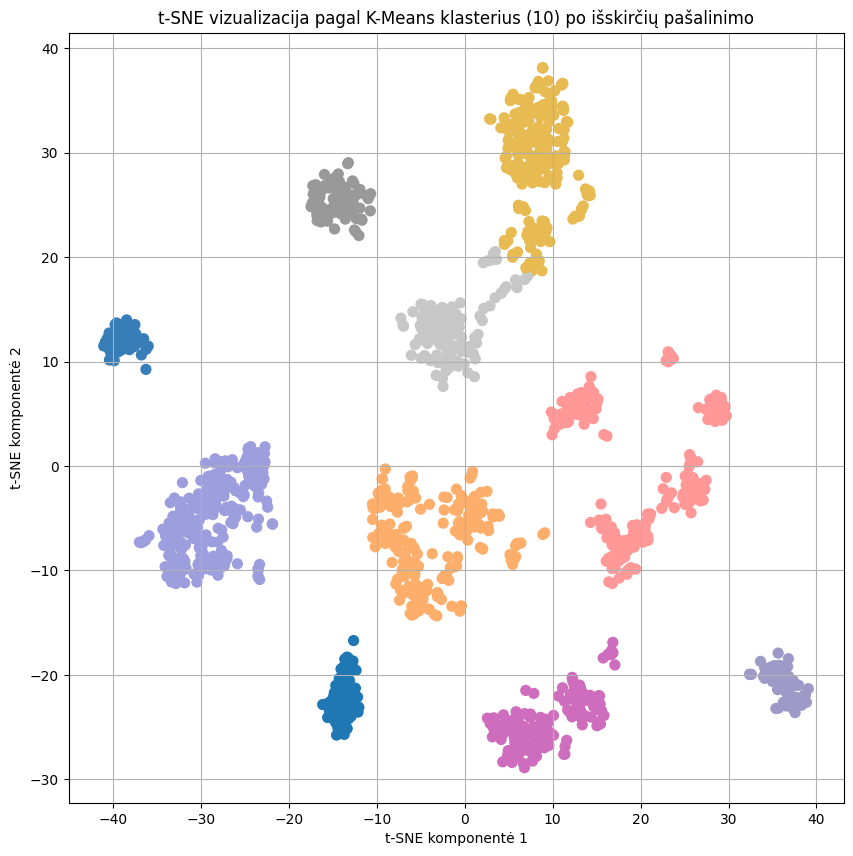

In [7]:
plt.figure(figsize=(10, 10))
colors = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors + plt.cm.Set1.colors
cmap = ListedColormap(colors)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_kmeans,
    cmap=cmap,
    s=50
)
plt.title(f"t-SNE vizualizacija pagal K-Means klasterius ({klasteriu_sk}) po išskirčių pašalinimo")
plt.xlabel("t-SNE komponentė 1")
plt.ylabel("t-SNE komponentė 2")
plt.grid(True)
plt.show()


In [8]:
from sklearn.metrics import silhouette_score

score_tsne = silhouette_score(X_tsne, y_kmeans)
print("Silueto koef. po t-SNE:", score_tsne)

Silueto koef. po t-SNE: 0.653139590811876


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

label_cluster_df = pd.crosstab(df['cluster'], df['label'], normalize='index') * 100

label_cluster_df.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Klasių pasiskirstymas klasteriuose", fontsize=13)
plt.xlabel("Klasteriai", fontsize=11)
plt.ylabel("Klasės dalis klasteryje (%)", fontsize=11)
plt.legend(title="Klasė", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


KeyError: 'label'

In [11]:
original_data = pd.read_csv("norm_6.csv")
original_data['cluster'] = y_kmeans
original_data.to_csv("kmeans_clustered(10)_original_data.csv", index=False)